load dataset


In [3]:
import pandas as pd

df = pd.read_csv("/content/sample_data/spotify-tracks-dataset-detailed.csv")

print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   
3  Can't Help Falling In Love          71       201933     False   
4   

find missing values

In [4]:
print(df.isnull().sum())

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


my importan variables

-danceability

-energy

-loudness

-tempo

-valence

-acousticness

-instrumentalness

-popularity

-track_genre

first important graphics

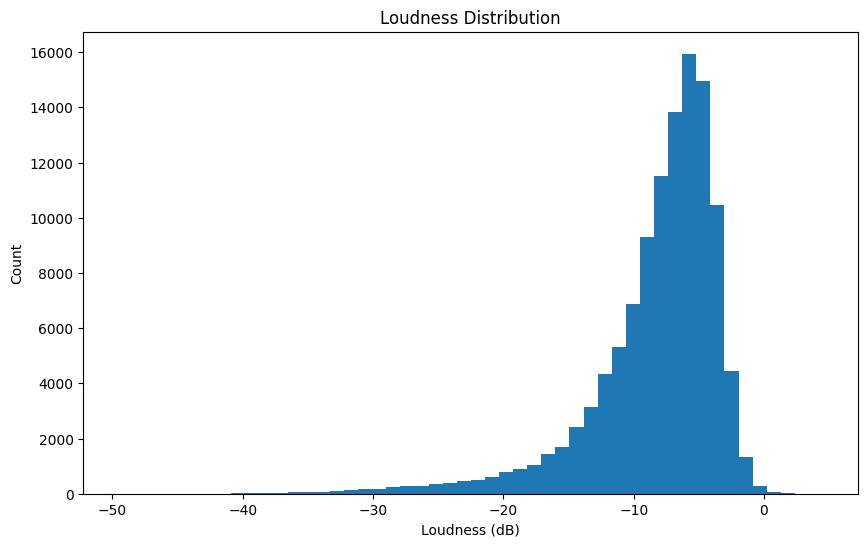

In [5]:
#loudness distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['loudness'], bins=50)
plt.title("Loudness Distribution")
plt.xlabel("Loudness (dB)")
plt.ylabel("Count")
plt.show()

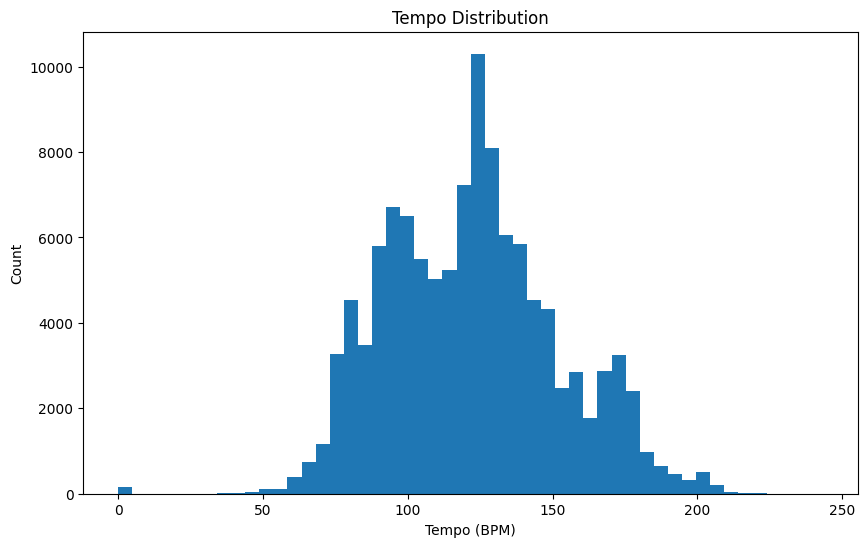

In [6]:
#tempo distribution

plt.figure(figsize=(10,6))
plt.hist(df['tempo'], bins=50)
plt.title("Tempo Distribution")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Count")
plt.show()

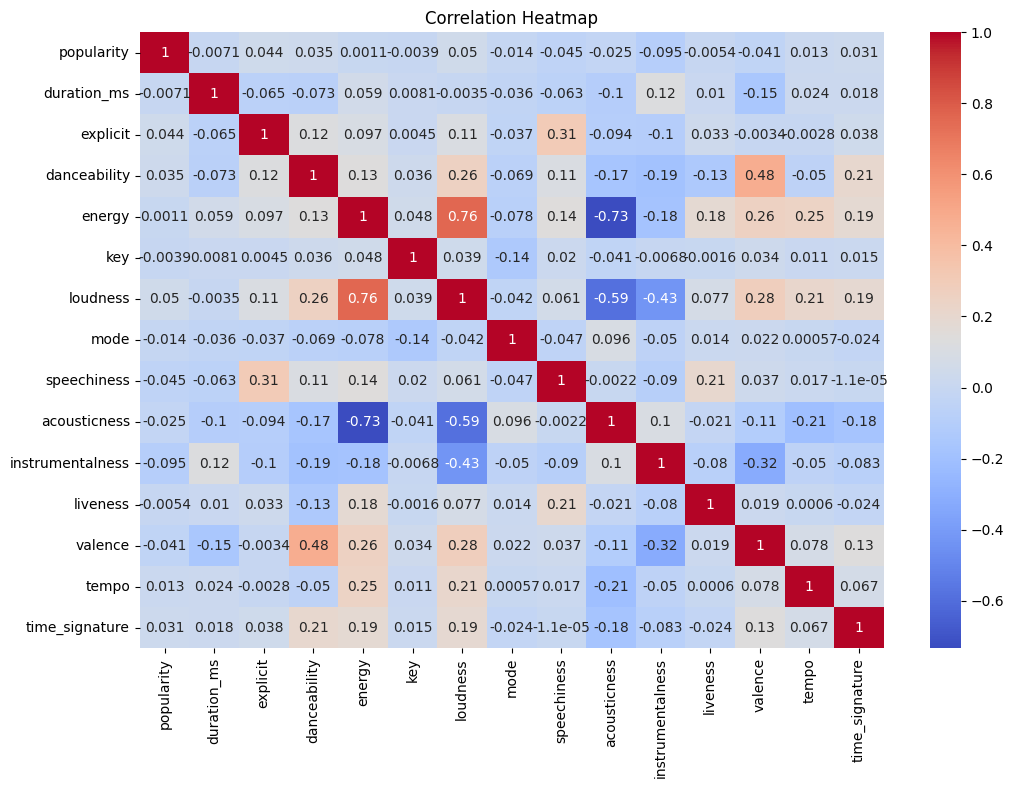

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

questions i came up with


"Do EDM genres have a higher average loudness than acoustic genres?"

or

"Is there a correlation within loudness and popularity?"

In [8]:
#eliminate duplicates

df = df.drop_duplicates()

print(df.shape)

(113550, 20)


In [9]:
#reduced dataset

audio_df = df[[
    'track_name',
    'artists',
    'track_genre',
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'valence',
    'tempo'
]]

print(audio_df.head())

                   track_name                 artists track_genre  popularity  \
0                      Comedy             Gen Hoshino    acoustic          73   
1            Ghost - Acoustic            Ben Woodward    acoustic          55   
2              To Begin Again  Ingrid Michaelson;ZAYN    acoustic          57   
3  Can't Help Falling In Love            Kina Grannis    acoustic          71   
4                     Hold On        Chord Overstreet    acoustic          82   

   danceability  energy  loudness  speechiness  acousticness  \
0         0.676  0.4610    -6.746       0.1430        0.0322   
1         0.420  0.1660   -17.235       0.0763        0.9240   
2         0.438  0.3590    -9.734       0.0557        0.2100   
3         0.266  0.0596   -18.515       0.0363        0.9050   
4         0.618  0.4430    -9.681       0.0526        0.4690   

   instrumentalness  valence    tempo  
0          0.000001    0.715   87.917  
1          0.000006    0.267   77.489  
2       

In [10]:
#check general stats

print(audio_df.describe())

          popularity   danceability         energy       loudness  \
count  113550.000000  113550.000000  113550.000000  113550.000000   
mean       33.324139       0.567031       0.642090      -8.243419   
std        22.283976       0.173408       0.251052       5.011401   
min         0.000000       0.000000       0.000000     -49.531000   
25%        17.000000       0.456000       0.473000      -9.997750   
50%        35.000000       0.580000       0.685000      -6.997000   
75%        50.000000       0.695000       0.854000      -5.001000   
max       100.000000       0.985000       1.000000       4.532000   

         speechiness   acousticness  instrumentalness        valence  \
count  113550.000000  113550.000000     113550.000000  113550.000000   
mean        0.084674       0.314067          0.155702       0.474207   
std         0.105761       0.331907          0.309216       0.259204   
min         0.000000       0.000000          0.000000       0.000000   
25%         0.0359

comparing genres


In [11]:
#top genres

top_genres = audio_df['track_genre'].value_counts().head(10)

print(top_genres)

track_genre
acoustic       1000
british        1000
electronic     1000
emo            1000
funk           1000
garage         1000
disco          1000
country        1000
rock           1000
rock-n-roll    1000
Name: count, dtype: int64


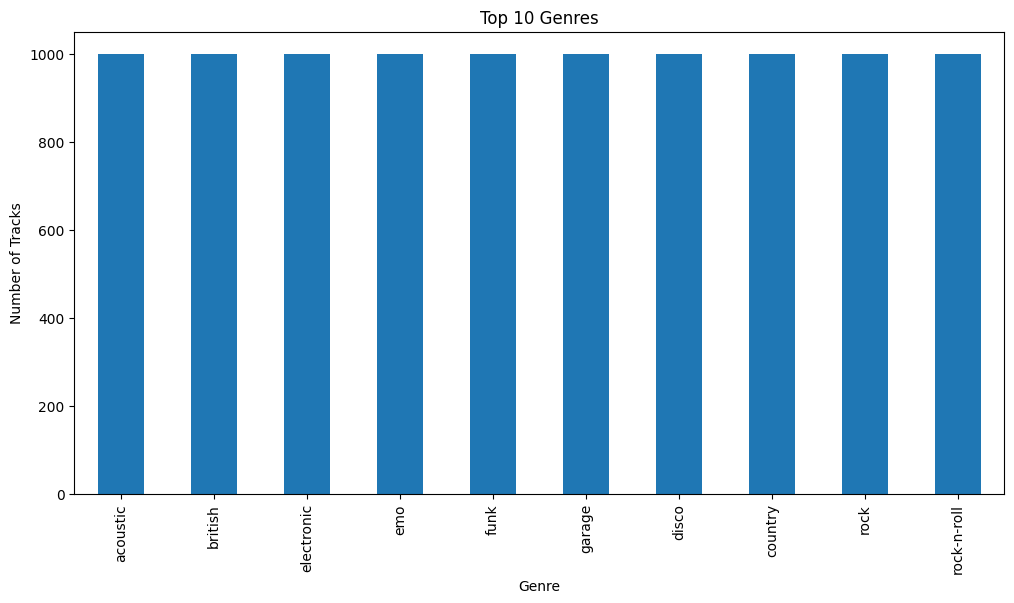

In [12]:
#top genres

import matplotlib.pyplot as plt

top_genres.plot(kind='bar', figsize=(12,6))

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")

plt.show()

important comp

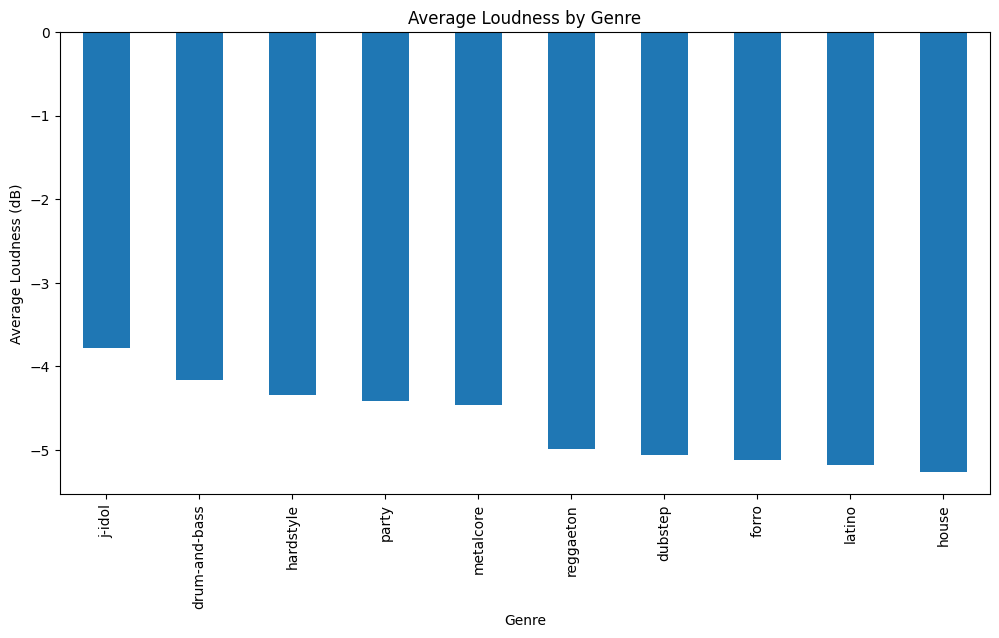

In [13]:
#average loudness by genre

genre_loudness = audio_df.groupby('track_genre')['loudness'].mean().sort_values(ascending=False).head(10)

genre_loudness.plot(kind='bar', figsize=(12,6))

plt.title("Average Loudness by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Loudness (dB)")

plt.show()

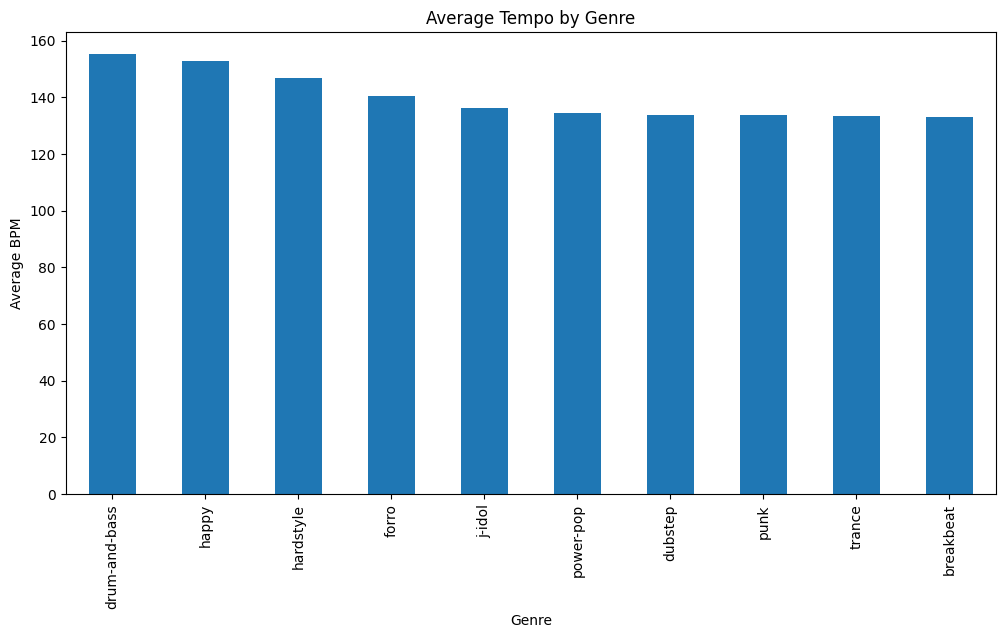

In [14]:
#average tempo by genre

genre_tempo = audio_df.groupby('track_genre')['tempo'].mean().sort_values(ascending=False).head(10)

genre_tempo.plot(kind='bar', figsize=(12,6))

plt.title("Average Tempo by Genre")
plt.xlabel("Genre")
plt.ylabel("Average BPM")

plt.show()

comparing genres

questions i came up with

-Which genres have the highest loudness?

-Which genres are the most energetic?

-Which genres have the highest danceability?

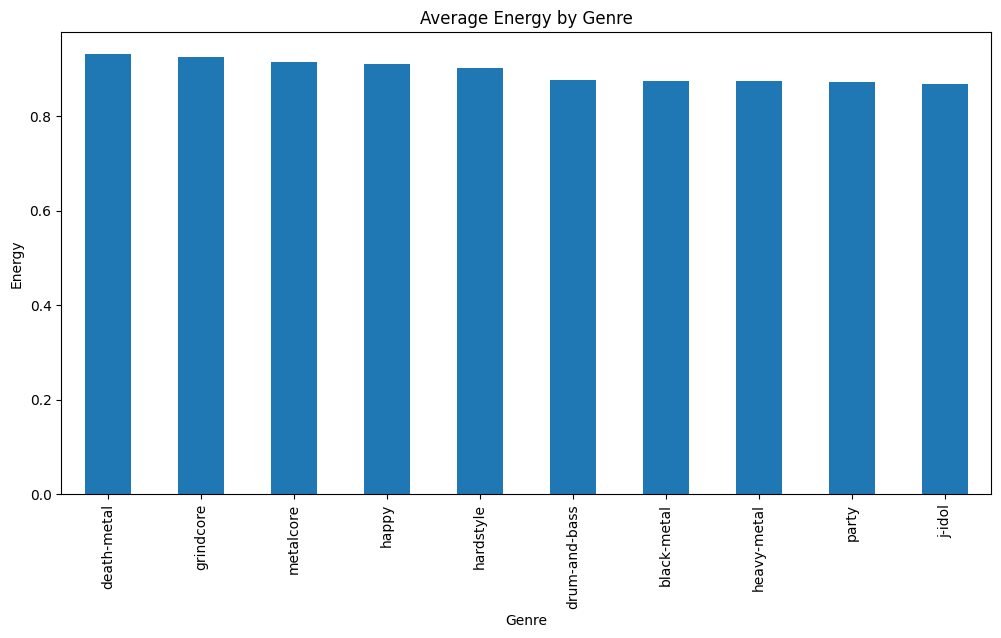

In [15]:
#average energy by genre

genre_energy = audio_df.groupby('track_genre')['energy'].mean().sort_values(ascending=False).head(10)

genre_energy.plot(kind='bar', figsize=(12,6))

plt.title("Average Energy by Genre")
plt.xlabel("Genre")
plt.ylabel("Energy")

plt.show()

popularity vs loudness

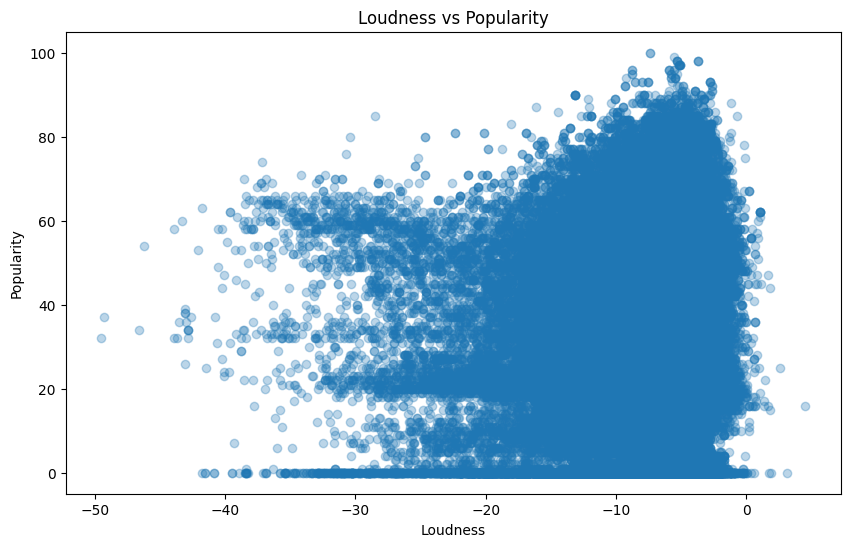

In [16]:

plt.figure(figsize=(10,6))

plt.scatter(audio_df['loudness'], audio_df['popularity'], alpha=0.3)

plt.title("Loudness vs Popularity")
plt.xlabel("Loudness")
plt.ylabel("Popularity")

plt.show()

Danceability vs energy

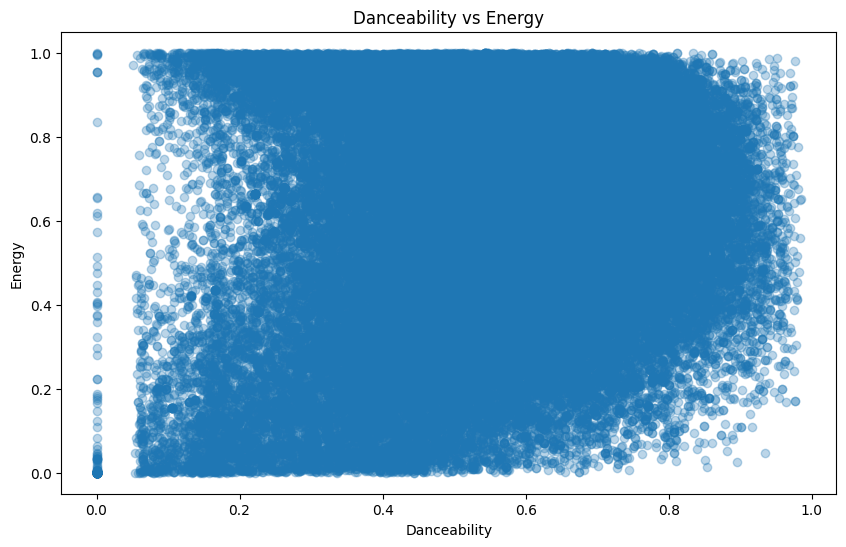

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(audio_df['danceability'], audio_df['energy'], alpha=0.3)

plt.title("Danceability vs Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")

plt.show()


correlation analysis

things to interprate

-Energy and loudness show strong positive correlation.

-Acousticness tends to negatively correlate with energy.

-Danceability may correlate with popularity.

In [18]:
#filter specific genres

selected_genres = ['electronic', 'house', 'techno', 'hip-hop']

filtered_df = audio_df[audio_df['track_genre'].isin(selected_genres)]

print(filtered_df.head())

                        track_name                    artists track_genre  \
32000                     Shootout  Izzamuzzic;Julien Marchal  electronic   
32001  A Different Way (with Lauv)              DJ Snake;Lauv  electronic   
32002                       Middle  DJ Snake;Bipolar Sunshine  electronic   
32003                      Iraaday       Rovalio;Abdul Hannan  electronic   
32004              Let Me Love You     DJ Snake;Justin Bieber  electronic   

       popularity  danceability  energy  loudness  speechiness  acousticness  \
32000          78         0.663   0.578    -9.079       0.0687        0.3120   
32001          66         0.784   0.757    -3.912       0.0384        0.4950   
32002          76         0.583   0.695    -5.336       0.0423        0.0141   
32003          66         0.737   0.458    -5.805       0.0317        0.6010   
32004          84         0.649   0.716    -5.371       0.0349        0.0863   

       instrumentalness  valence    tempo  
32000       

more specific comparissons

-loudness within electronic and hip-hop

-average BPM

-average danceability

-average energy

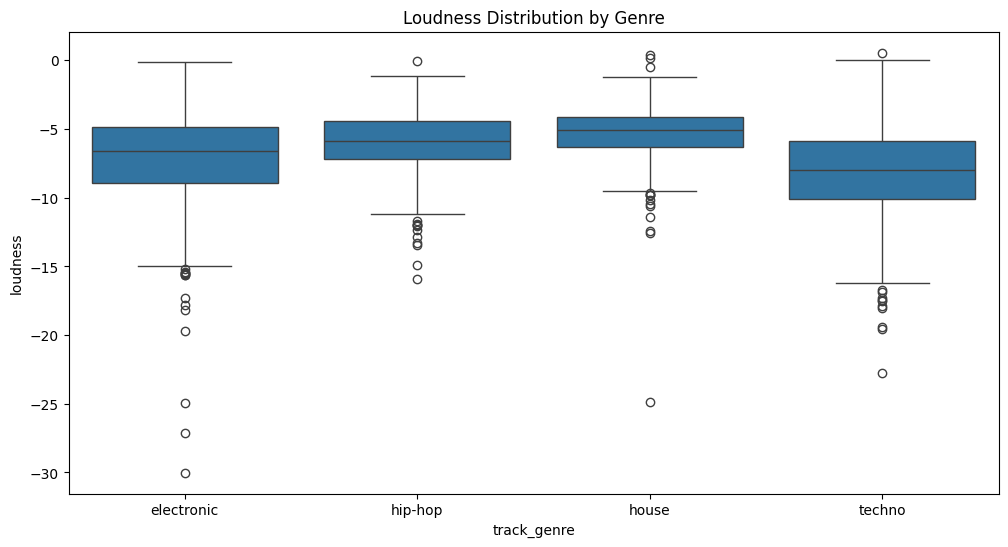

In [19]:
#boxplots

import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=filtered_df,
    x='track_genre',
    y='loudness'
)

plt.title("Loudness Distribution by Genre")

plt.show()

what i found out

-Electronic genres tend to exhibit higher average loudness levels compared to acoustic genres

-Danceability and energy appear strongly correlated in modern EDM tracks.

-Genres with higher loudness often show increased popularity scores.

pick specific genres

In [20]:
audio_df = df[[
    'track_name',
    'artists',
    'track_genre',
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'valence',
    'tempo'
]]

print(audio_df.head())

                   track_name                 artists track_genre  popularity  \
0                      Comedy             Gen Hoshino    acoustic          73   
1            Ghost - Acoustic            Ben Woodward    acoustic          55   
2              To Begin Again  Ingrid Michaelson;ZAYN    acoustic          57   
3  Can't Help Falling In Love            Kina Grannis    acoustic          71   
4                     Hold On        Chord Overstreet    acoustic          82   

   danceability  energy  loudness  speechiness  acousticness  \
0         0.676  0.4610    -6.746       0.1430        0.0322   
1         0.420  0.1660   -17.235       0.0763        0.9240   
2         0.438  0.3590    -9.734       0.0557        0.2100   
3         0.266  0.0596   -18.515       0.0363        0.9050   
4         0.618  0.4430    -9.681       0.0526        0.4690   

   instrumentalness  valence    tempo  
0          0.000001    0.715   87.917  
1          0.000006    0.267   77.489  
2       

In [21]:
selected_genres = [
    'electronic',
    'house',
    'techno',
    'hip-hop'
]

filtered_df = audio_df[
    audio_df['track_genre'].isin(selected_genres)
]

print(filtered_df['track_genre'].value_counts())

track_genre
electronic    1000
techno        1000
house          999
hip-hop        991
Name: count, dtype: int64


genre compare

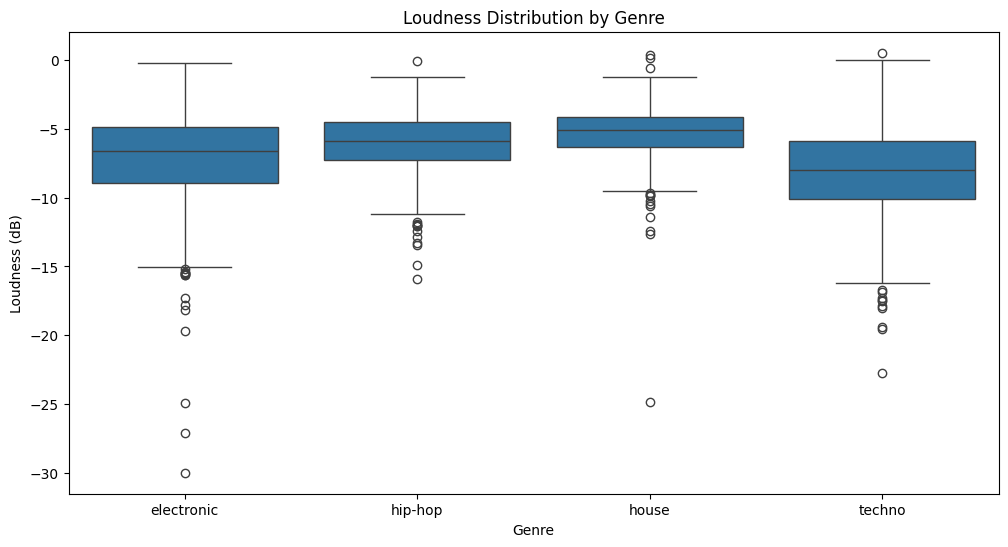

In [22]:
#boxplot loudness per genre

plt.figure(figsize=(12,6))

sns.boxplot(
    data=filtered_df,
    x='track_genre',
    y='loudness'
)

plt.title("Loudness Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Loudness (dB)")

plt.show()

ML

clutering

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [24]:
#choose features

features = filtered_df[[
    'danceability',
    'energy',
    'loudness',
    'tempo'
]]

In [25]:
#scaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [26]:
#clear clusters

kmeans = KMeans(n_clusters=4, random_state=42)

filtered_df['cluster'] = kmeans.fit_predict(scaled_features)

/tmp/ipykernel_6891/1669004215.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['cluster'] = kmeans.fit_predict(scaled_features)


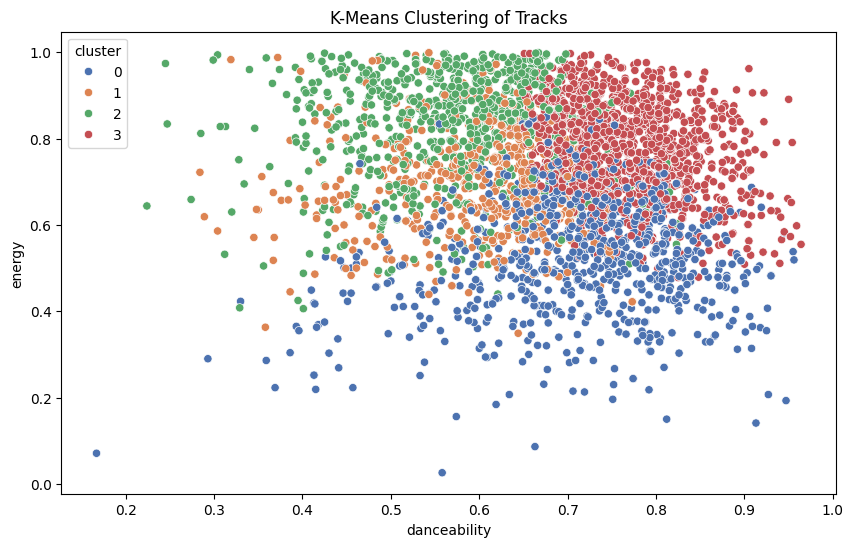

In [27]:
#visualize cluster

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered_df,
    x='danceability',
    y='energy',
    hue='cluster',
    palette='deep'
)

plt.title("K-Means Clustering of Tracks")

plt.show()

K-means clustering

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [29]:
#important features

features = filtered_df[[
    'danceability',
    'energy',
    'loudness',
    'tempo'
]]

In [30]:
#scaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [31]:
#clear clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

filtered_df['cluster'] = kmeans.fit_predict(
    scaled_features
)

/tmp/ipykernel_6891/433541393.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['cluster'] = kmeans.fit_predict(


In [32]:
#visualize clusters

print(filtered_df[['track_genre', 'cluster']].head(20))

      track_genre  cluster
32000  electronic        0
32001  electronic        3
32002  electronic        1
32003  electronic        1
32004  electronic        1
32005  electronic        3
32006  electronic        0
32007  electronic        0
32008  electronic        1
32009  electronic        0
32010  electronic        0
32011  electronic        2
32012  electronic        1
32013  electronic        1
32014  electronic        1
32015  electronic        3
32016  electronic        2
32017  electronic        3
32018  electronic        1
32019  electronic        2


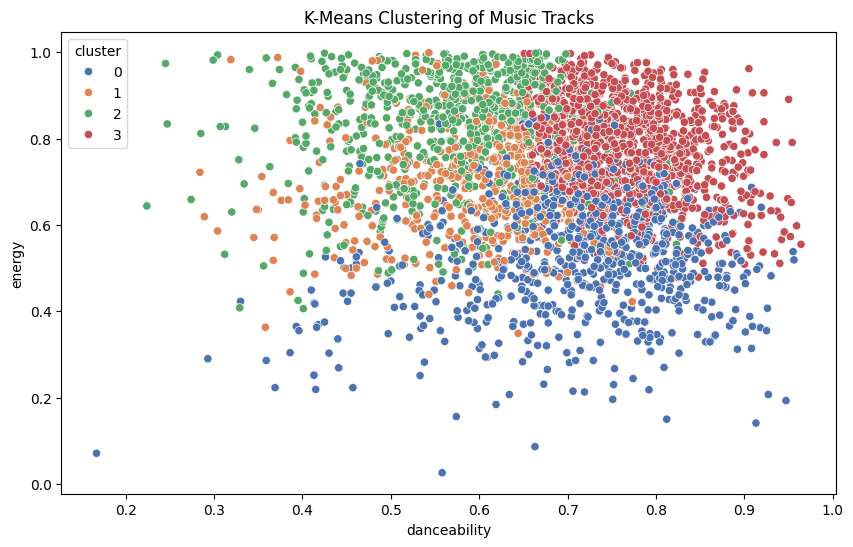

In [33]:
#visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered_df,
    x='danceability',
    y='energy',
    hue='cluster',
    palette='deep'
)

plt.title("K-Means Clustering of Music Tracks")

plt.show()

pca visualization

In [34]:
#import PCA

from sklearn.decomposition import PCA

In [35]:
#create PCA

pca = PCA(n_components=2)

In [36]:
#apply PCA

pca_features = pca.fit_transform(
    scaled_features
)

In [37]:
#new columns

filtered_df['PCA1'] = pca_features[:,0]
filtered_df['PCA2'] = pca_features[:,1]

/tmp/ipykernel_6891/3338644822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['PCA1'] = pca_features[:,0]
/tmp/ipykernel_6891/3338644822.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['PCA2'] = pca_features[:,1]


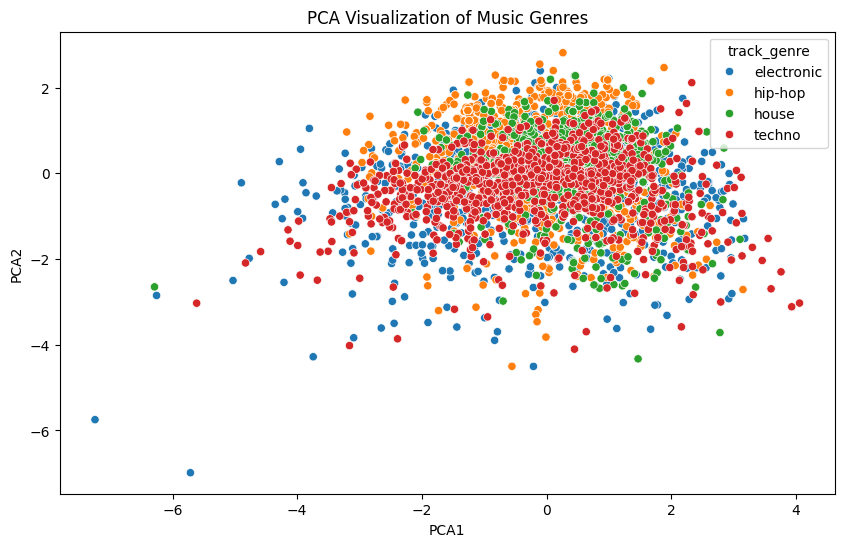

In [38]:
#PCA Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered_df,
    x='PCA1',
    y='PCA2',
    hue='track_genre'
)

plt.title("PCA Visualization of Music Genres")

plt.show()

-Electronic and house genres tend to cluster closely in PCA space, suggesting similar audio feature distributions related to energy and danceability

-Hip-hop tracks appear more dispersed, indicating greater variability in musical characteristics.


classification model

In [39]:
#imports

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [40]:
#features & labels

X = filtered_df[[
    'danceability',
    'energy',
    'loudness',
    'tempo'
]]

y = filtered_df['track_genre']

In [41]:
#train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
#create model

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [43]:
#predictions

y_pred = model.predict(X_test)

In [44]:
#accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6040100250626567


In [45]:
#classification report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

  electronic       0.48      0.36      0.41       211
     hip-hop       0.68      0.73      0.70       207
       house       0.61      0.67      0.64       187
      techno       0.62      0.67      0.64       193

    accuracy                           0.60       798
   macro avg       0.59      0.61      0.60       798
weighted avg       0.59      0.60      0.60       798



Feature Importance analysis

In [46]:
#feature importance

importance = model.feature_importances_

feature_names = X.columns

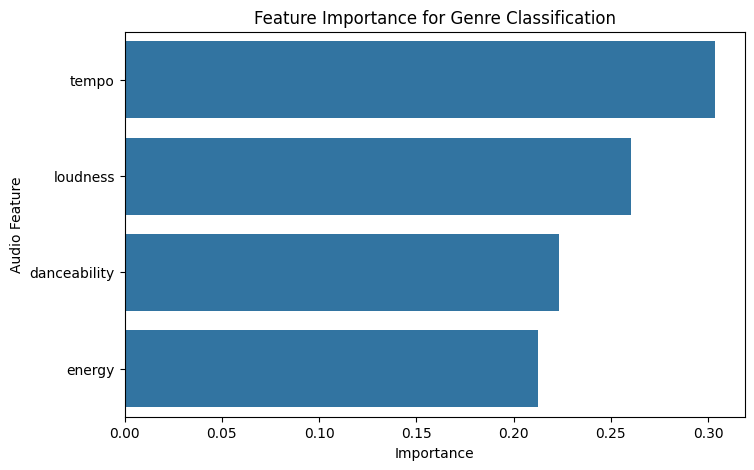

In [47]:
#visualization



plt.show()

importance = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance for Genre Classification")
plt.xlabel("Importance")
plt.ylabel("Audio Feature")

plt.show()

confusion matrix

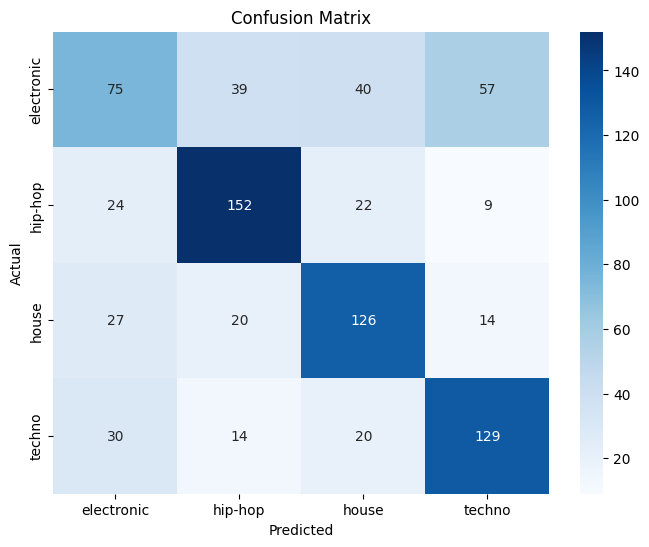

In [48]:
#confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Feature Distribution Comparisons

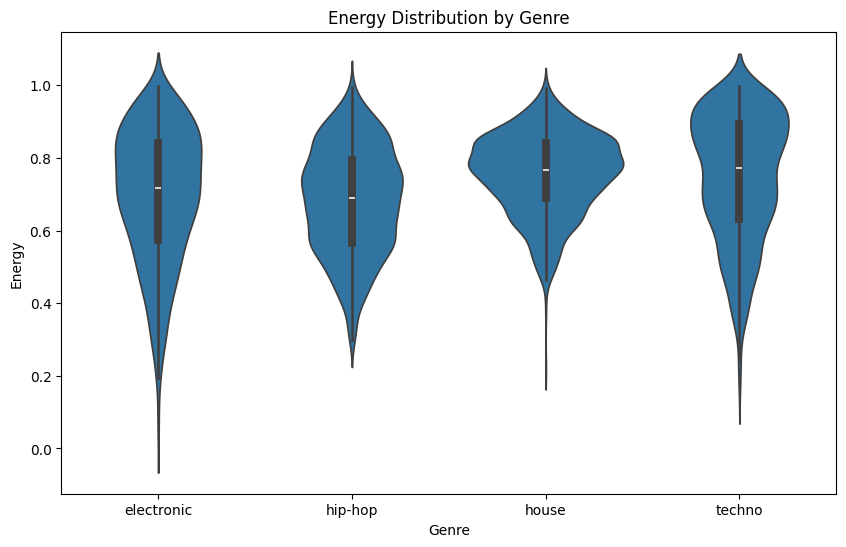

In [49]:
#energy by genre

plt.figure(figsize=(10,6))

sns.violinplot(
    data=filtered_df,
    x='track_genre',
    y='energy'
)

plt.title("Energy Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Energy")

plt.show()

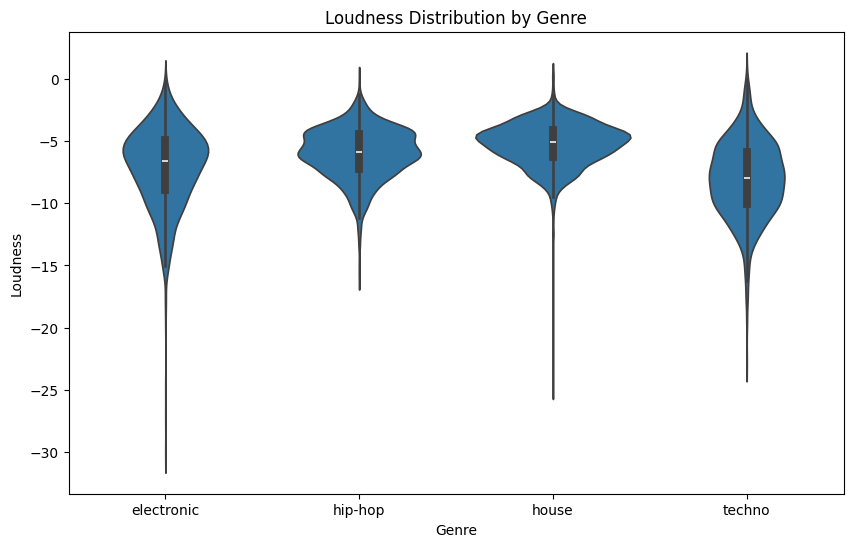

In [50]:
#loudness by genre

plt.figure(figsize=(10,6))

sns.violinplot(
    data=filtered_df,
    x='track_genre',
    y='loudness'
)

plt.title("Loudness Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Loudness")

plt.show()

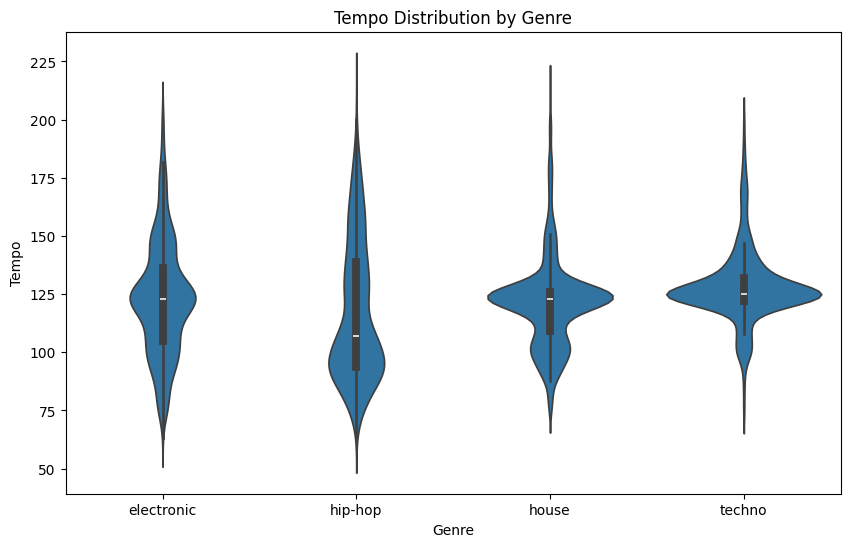

In [51]:
#tempo by genre

plt.figure(figsize=(10,6))

sns.violinplot(
    data=filtered_df,
    x='track_genre',
    y='tempo'
)

plt.title("Tempo Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Tempo")

plt.show()

Real-world audio measurements

In [52]:
daw_data = pd.DataFrame({

          'Track': [
        'Butterfly Effect',
        'Am I Dreaming',
        'Jungle',
        'Move A Little Closer',
        'Losing It',
        'Amor',
    ],
        'Genre': [
        'Hip-Hop',
        'Hip-Hop',
        'EDM',
        'EDM',
        'House - Techno',
        'House - Techno',
    ],

    'LUFS': [
        -8.5,
        -8.3,
        -8.2,
        -7.6,
        -7.8,
        -6.8,
    ],
'True Peak': [
        -0.5,
        -0.3,
        -0.5,
        1.1,
        0.7,
        1.1,
    ],
  'LRA': [
        0.9,
        4.3,
        4.6,
        4.5,
        0.6,
        2.5,
    ]
})

print(daw_data)

                  Track           Genre  LUFS  True Peak  LRA
0      Butterfly Effect         Hip-Hop  -8.5       -0.5  0.9
1         Am I Dreaming         Hip-Hop  -8.3       -0.3  4.3
2                Jungle             EDM  -8.2       -0.5  4.6
3  Move A Little Closer             EDM  -7.6        1.1  4.5
4             Losing It  House - Techno  -7.8        0.7  0.6
5                  Amor  House - Techno  -6.8        1.1  2.5


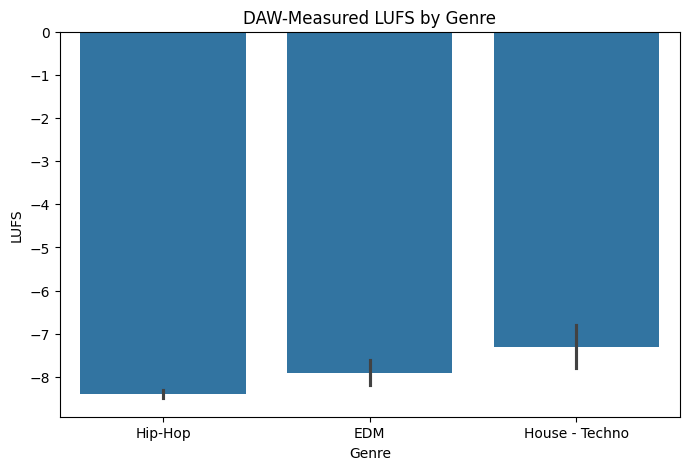

In [53]:
#graph LUFS

plt.figure(figsize=(8,5))

sns.barplot(
    data=daw_data,
    x='Genre',
    y='LUFS'
)

plt.title("DAW-Measured LUFS by Genre")

plt.show()

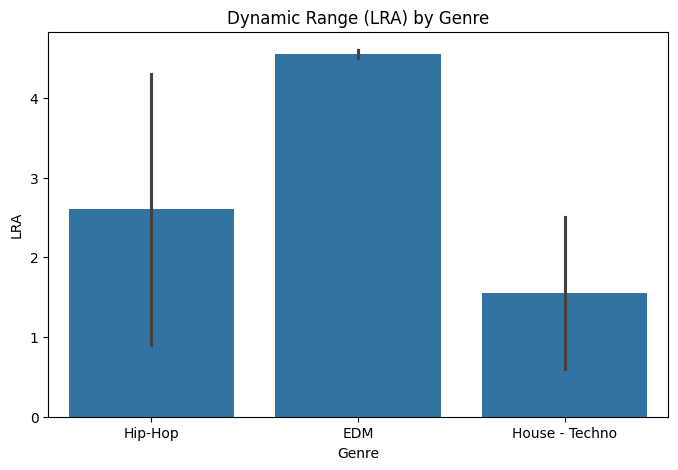

In [54]:
#graph LRA

plt.figure(figsize=(8,5))

sns.barplot(
    data=daw_data,
    x='Genre',
    y='LRA'
)

plt.title("Dynamic Range (LRA) by Genre")

plt.show()

EDM tracks exhibited higher loudness levels and lower loudness range values, suggesting more aggressive mastering and reduced dynamic variation compared to hip-hop tracks

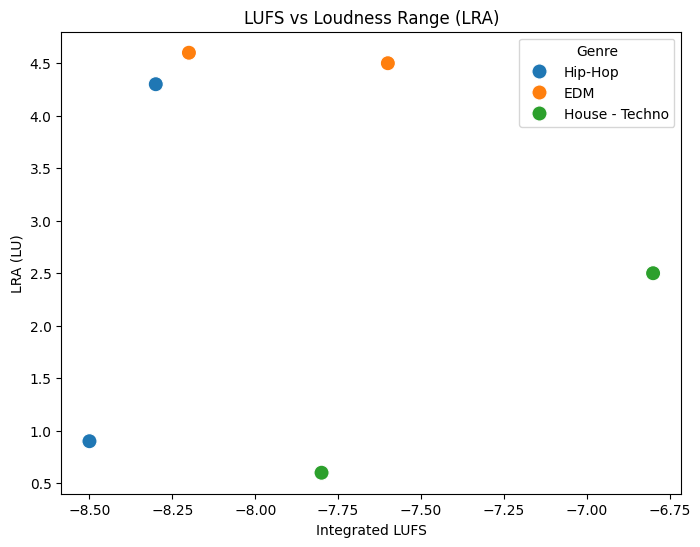

In [55]:
#graph LUFS vs LRA

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=daw_data,
    x='LUFS',
    y='LRA',
    hue='Genre',
    s=120
)

plt.title("LUFS vs Loudness Range (LRA)")
plt.xlabel("Integrated LUFS")
plt.ylabel("LRA (LU)")

plt.show()

Tracks with higher loudness levels generally exhibited lower loudness range values, suggesting more aggressive compression and limiting practices.

conclussions and insights


- Tracks with lower LRA values demonstrated more consistent loudness levels throughout the song structure, indicating reduced dynamic variation.

- PCA visualization showed that electronic and house tracks tend to cluster closely due to similar audio feature distributions.

- Electronic and EDM tracks generally exhibited higher loudness levels and lower loudness range values, suggesting more aggressive mastering and dynamic compression techniques.